# SentinelMail — Ensemble: Weight Learning & Evaluation

Confidence-weighted **per-category late fusion** of the four models
(BERT, RoBERTa, Bi-LSTM, rule-based). This notebook fits per-label fusion
weights + thresholds on a **DEV** partition (the seeded 10% held-out slice of
`train` — the same slice neural checkpoint selection used) and reports all final
metrics on the **untouched TEST** split (the full ai4privacy `validation` split,
touched exactly once). DEV and TEST are fully disjoint, so the ensemble gets no
peek at the rows it is scored on (avoids tuning-on-test bias). Single models are
re-evaluated on the same TEST split for a fair, apples-to-apples RQ1 comparison.

**Prerequisite:** all four model checkpoints must exist under `models/*/checkpoint/`.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

RESULTS_DIR = REPO_ROOT / "evaluation" / "results"
ENSEMBLE_DIR = REPO_ROOT / "ensemble"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
RANDOM_STATE = 42
THRESHOLD = 0.5
print(f"Device: {DEVICE}")

Device: mps


In [2]:
from ensemble import (
    build_cache,
    load_probas,
    fit_weights,
    tune_thresholds,
    save_weights,
    save_thresholds,
)
from evaluation import (
    LABEL_COLS,
    compute_all_metrics,
    fuse,
    run_ablation,
    ensemble_vs_best_single,
    plot_ablation_table,
    plot_model_comparison_table,
    plot_confusion_matrices,
    plot_per_label_bars,
    plot_roc_curves,
    plot_pr_curves,
    save_results,
)

/Users/erelv/projects-chkp/final-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Build / Load Probability Caches (DEV + TEST)

`build_cache` runs each detector's `predict_proba` once over a split and caches
the arrays (BERT/RoBERTa CPU inference is the bottleneck). We build two disjoint
caches:

- **DEV** = `train_holdout` (seeded 10% slice of `train`) — used to fit weights/thresholds.
- **TEST** = `validation` (full ai4privacy validation split) — used for reporting only.

Both are idempotent — re-running is instant unless the split text changes. The
loader verifies an sha1 of the ordered emails so every model's rows are aligned.

In [3]:
DEV_SPLIT = "train_holdout"   # seeded 10% held-out slice of `train`
TEST_SPLIT = "validation"     # untouched TEST split, reported once

build_cache(split=DEV_SPLIT, device=str(DEVICE))
build_cache(split=TEST_SPLIT, device=str(DEVICE))

dev_probas, dev_y, dev_texts = load_probas(split=DEV_SPLIT)
eval_probas, eval_y, eval_texts = load_probas(split=TEST_SPLIT)

print(f"DEV (fit):   {dev_y.shape[0]:,} emails")
print(f"TEST (report): {eval_y.shape[0]:,} emails; models: {list(eval_probas)}")
for name, arr in eval_probas.items():
    print(f"  {name:12s} {arr.shape}  range [{arr.min():.3f}, {arr.max():.3f}]")

[cache] running bert on 2991 emails ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9103.33it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[cache] running roberta on 2991 emails ...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9078.78it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[cache] running bilstm on 2991 emails ...
[cache] running rule_based on 2991 emails ...
[cache] wrote 4 models + labels for split='train_holdout' to /Users/erelv/projects-chkp/final-project/ensemble/cache
[cache] up to date for split='validation' (n=7946); use force=True to rebuild.
DEV (fit):   2,991 emails
TEST (report): 7,946 emails; models: ['bert', 'roberta', 'bilstm', 'rule_based']
  bert         (7946, 4)  range [0.003, 0.998]
  roberta      (7946, 4)  range [0.003, 0.998]
  bilstm       (7946, 4)  range [0.000, 1.000]
  rule_based   (7946, 4)  range [0.000, 1.000]


## 2. DEV / TEST Partitions

DEV (`train_holdout`) and TEST (`validation`) come from disjoint dataset splits —
DEV is carved from `train`, TEST is the untouched ai4privacy `validation` split.
Weights and thresholds are fit on **DEV**; all reported metrics (ensemble and
single models) come from **TEST**. No in-notebook re-splitting of the reporting
split is needed.

In [4]:
# DEV and TEST are already disjoint splits loaded above; no re-splitting needed.
assert dev_y.shape[0] > 0 and eval_y.shape[0] > 0
print(f"DEV: {dev_y.shape[0]:,} (train_holdout)   TEST: {eval_y.shape[0]:,} (validation)")

DEV: 2,991 (train_holdout)   TEST: 7,946 (validation)


## 3. Fit Per-Category Weights (on DEV)

Per-label grid + Nelder-Mead search on the **true** binary F1. Fusion is
separable per label, so each label's four model-weights are optimised
independently. (`fit_weights_lbfgsb` is available as the spec-letter surrogate
alternative — see `ensemble/train_weights.py`.)

In [5]:
weights = fit_weights(dev_probas, dev_y, threshold=THRESHOLD)
thresholds = tune_thresholds(dev_probas, dev_y, weights)

save_weights(weights, ENSEMBLE_DIR / "weights.json")
save_thresholds(thresholds, ENSEMBLE_DIR / "thresholds.json")
print("Saved weights.json and thresholds.json")
print("Tuned per-label thresholds:", thresholds)

Saved weights.json and thresholds.json
Tuned per-label thresholds: {'benign': 0.65, 'PII': 0.39999999999999997, 'financial': 0.49999999999999994, 'confidential': 0.49999999999999994}


### 3a. Learned Weights (RQ2 — does complementarity vary by category?)

In [6]:
weights_df = pd.DataFrame(weights).T[LABEL_COLS].round(3)  # rows=model, cols=label
weights_df

,benign,PII,financial,confidential
bert,0.697,0.8,0.2,0.000
roberta,0.100,0.0,0.0,0.512
bilstm,0.104,0.1,0.5,0.390
rule_based,0.100,0.1,0.3,0.098


## 4. Evaluate Ensemble (untouched TEST split — full `validation`)

In [7]:
# Headline ensemble result uses the DEV-tuned per-label thresholds (comment 017, Decision A1).
y_pred_e, y_proba_e = fuse(eval_probas, weights, threshold=thresholds)
metrics = compute_all_metrics(eval_y, y_pred_e, y_proba=y_proba_e)

ci = metrics["macro_f1_ci"]
print(f"Ensemble macro-F1: {metrics['macro_f1']:.4f}  "
      f"95% CI [{ci['lower']:.4f}, {ci['upper']:.4f}]")
for label in LABEL_COLS:
    print(f"  {label:12s} F1={metrics['per_label'][label]['f1']:.4f}")

Ensemble macro-F1: 0.9703  95% CI [0.9669, 0.9736]
  benign       F1=0.9342
  PII          F1=0.9906
  financial    F1=0.9456
  confidential F1=0.9745


### 4a. Threshold Sensitivity (0.3 / 0.5 / 0.7 + tuned per-label)

In [8]:
rows = []
for t in [0.3, 0.5, 0.7]:
    m = compute_all_metrics(eval_y, (y_proba_e >= t).astype(np.int32), n_bootstrap=50)
    row = {"config": f"fixed@{t}", "macro_f1": round(m["macro_f1"], 4)}
    for label in LABEL_COLS:
        row[f"{label}_f1"] = round(m["per_label"][label]["f1"], 4)
    rows.append(row)

# tuned per-label thresholds
y_pred_tuned = np.stack(
    [(y_proba_e[:, i] >= thresholds[label]).astype(np.int32)
     for i, label in enumerate(LABEL_COLS)], axis=1)
m = compute_all_metrics(eval_y, y_pred_tuned, n_bootstrap=50)
row = {"config": "tuned_per_label", "macro_f1": round(m["macro_f1"], 4)}
for label in LABEL_COLS:
    row[f"{label}_f1"] = round(m["per_label"][label]["f1"], 4)
rows.append(row)

pd.DataFrame(rows).set_index("config")

,macro_f1,benign_f1,PII_f1,financial_f1,confidential_f1
config,,,,,
fixed@0.3,0.9578,0.7059,0.9915,0.9133,0.9687
fixed@0.5,0.9698,0.9223,0.9892,0.9456,0.9745
fixed@0.7,0.8551,0.9389,0.9486,0.6562,0.9606
tuned_per_label,0.9703,0.9342,0.9906,0.9456,0.9745


## 5. Ablation Study (RQ1 — does the ensemble beat any single model?)

`run_ablation` reports the full ensemble, each leave-one-model-out
configuration, every solo model, and the best single model — all on the untouched
TEST split (full `validation`, same rows as the ensemble) with 95% bootstrap CIs.

Ensemble macro-F1 = 0.97025 vs best single (roberta) macro-F1 = 0.97058
delta = -0.00032  95% CI [-0.00293, +0.00237]  bootstrap p = 0.8000
RQ1 VERDICT: NOT SIGNIFICANT — delta CI includes 0; no significant ensemble gain over the best single model.


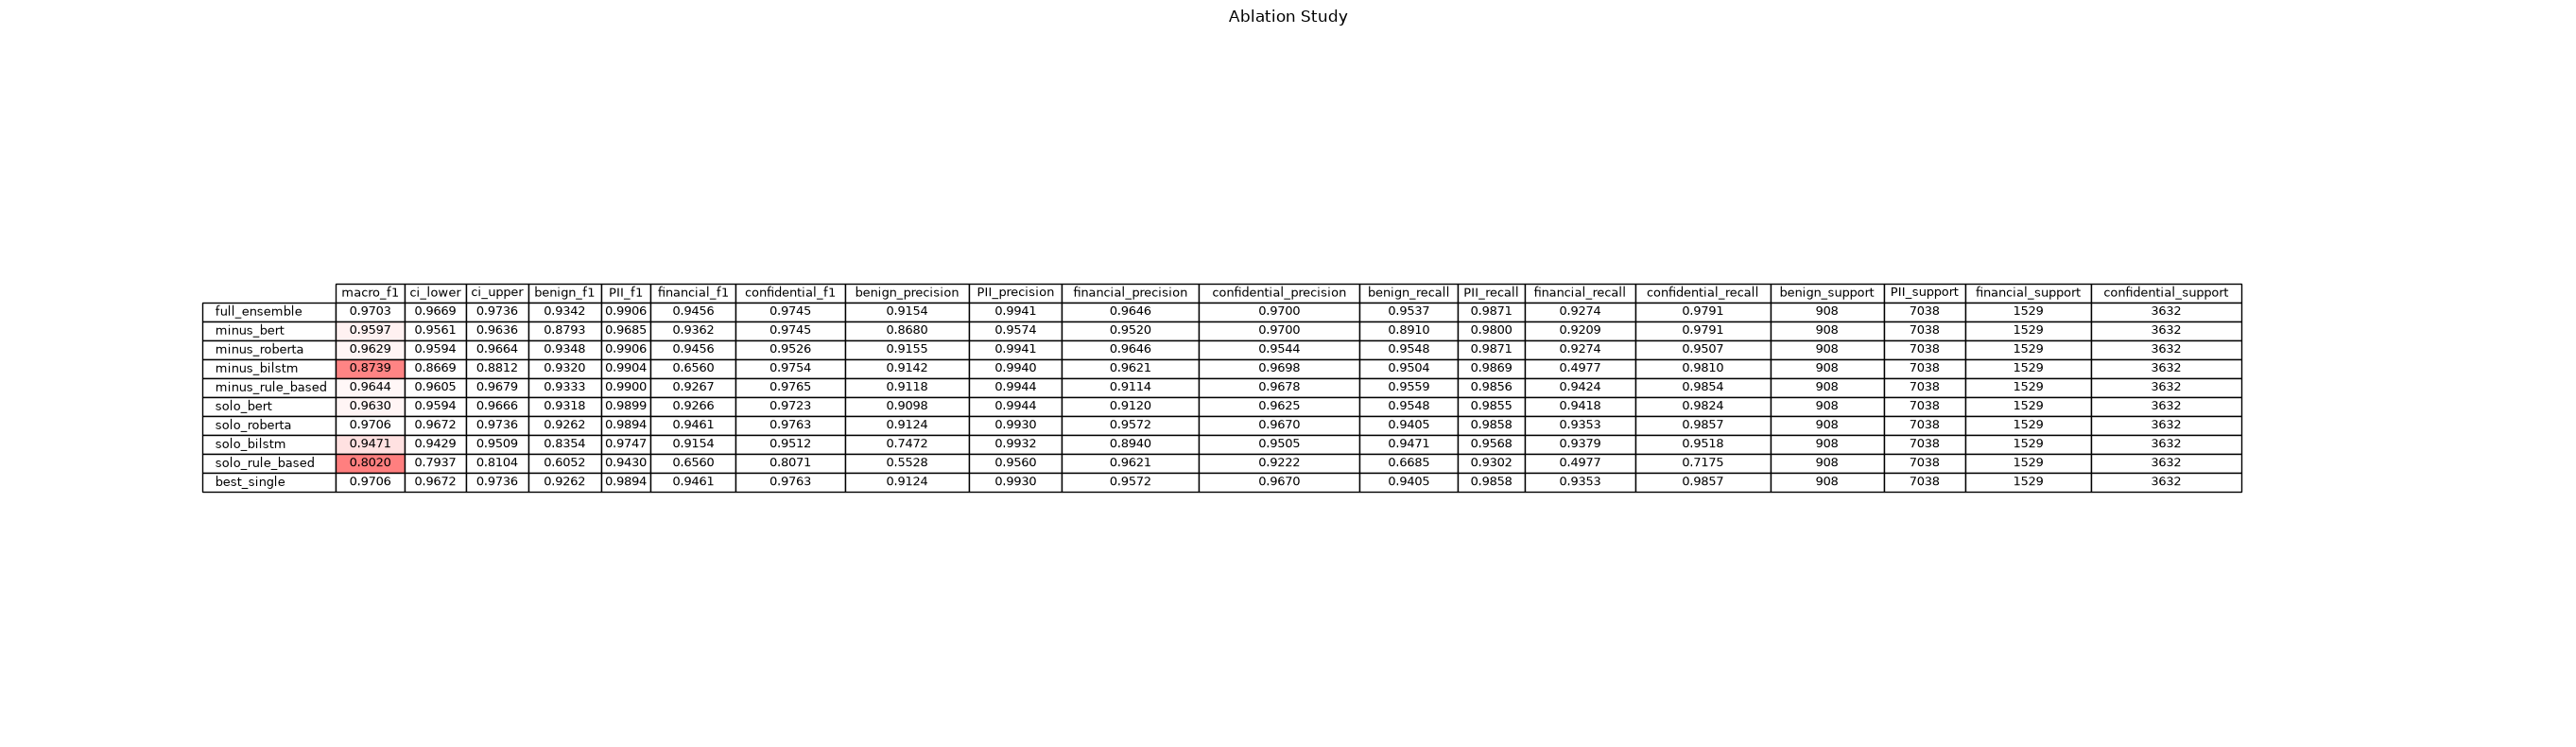

In [9]:
# RQ1/ablation: the SAME DEV-tuned per-label thresholds are applied to the
# ensemble AND to every single model (comment 017 Decision B1 / comment 010),
# so all rows are apples-to-apples. NOTE: a single model's F1 in THIS table is
# computed at the tuned thresholds; that same model's own headline result file
# (evaluation/results/<model>_metrics.json) remains reported at 0.5.
ablation_df = run_ablation(eval_probas, weights, eval_y, threshold=thresholds)
plot_ablation_table(ablation_df)

# RQ1 significance gate: paired bootstrap on macro-F1 delta (ensemble - best single),
# same TEST rows resampled for both configs. Claim a gain only if the delta CI excludes 0.
rq1 = ensemble_vs_best_single(eval_probas, weights, eval_y, threshold=thresholds)
print(
    f"Ensemble macro-F1 = {rq1['ensemble_macro_f1']:.5f} vs "
    f"best single ({rq1['best_single_model']}) macro-F1 = {rq1['best_single_macro_f1']:.5f}"
)
print(
    f"delta = {rq1['mean_delta']:+.5f}  "
    f"95% CI [{rq1['ci_lower']:+.5f}, {rq1['ci_upper']:+.5f}]  "
    f"bootstrap p = {rq1['p_value']:.4f}"
)
if rq1['significant']:
    print('RQ1 VERDICT: SIGNIFICANT — delta CI excludes 0; ensemble outperforms the best single model.')
else:
    print('RQ1 VERDICT: NOT SIGNIFICANT — delta CI includes 0; no significant ensemble gain over the best single model.')


## 6. Model Comparison (recomputed on the same TEST split)

Single-model metrics are recomputed here from the cached TEST probabilities at
threshold 0.5 — the same untouched `validation` split the ensemble is reported
on, so the RQ1 comparison is apples-to-apples. The per-model result JSONs in
`evaluation/results/` should also be regenerated on this TEST split (see comment 001).

,macro_f1,macro_f1_ci,benign_f1,PII_f1,financial_f1,confidential_f1
model,,,,,,
ensemble,0.970250,"[0.967, 0.974]",0.934196,0.990589,0.945649,0.974514
bert,0.962369,"[0.959, 0.966]",0.909849,0.988128,0.926641,0.972340
roberta,0.969921,"[0.967, 0.973]",0.913502,0.987409,0.946080,0.976275
bilstm,0.946579,"[0.942, 0.950]",0.825427,0.973157,0.915417,0.951162
rule_based,0.802020,"[0.794, 0.810]",0.605184,0.942964,0.656034,0.807061


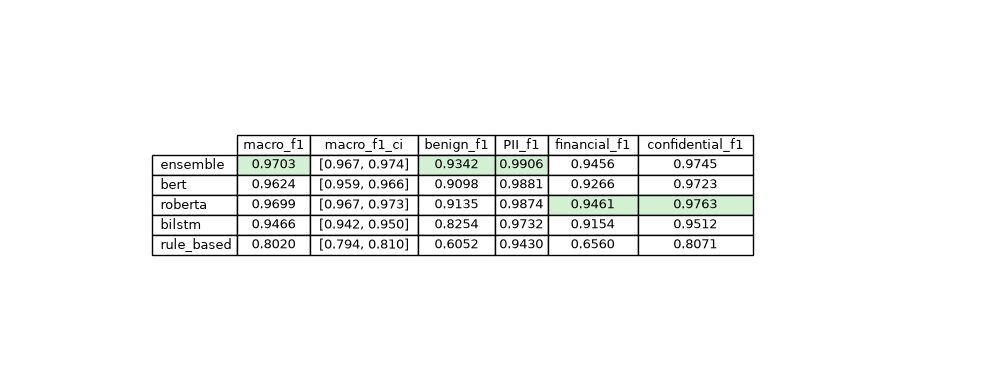

In [10]:
results = {"ensemble": metrics}
for name, probas in eval_probas.items():
    y_pred_m = (probas >= THRESHOLD).astype(np.int32)
    # rule_based produces binary 0/1 flags, not calibrated probabilities -> y_proba=None
    y_proba_m = None if name == "rule_based" else probas
    results[name] = compute_all_metrics(eval_y, y_pred_m, y_proba=y_proba_m)

plot_model_comparison_table(results)

## 7. Confusion Matrices, Per-Label Bars, ROC & PR Curves

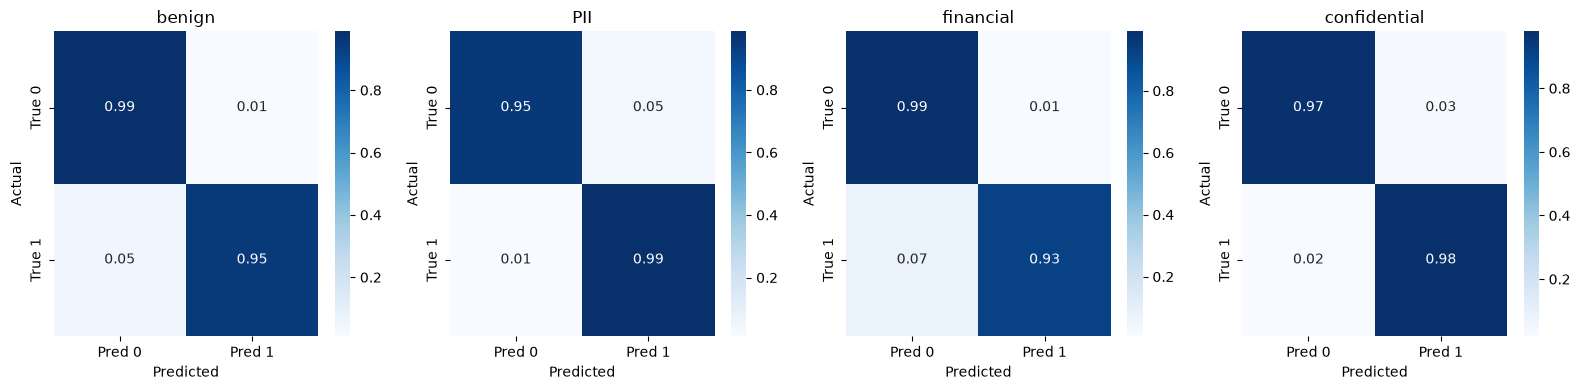

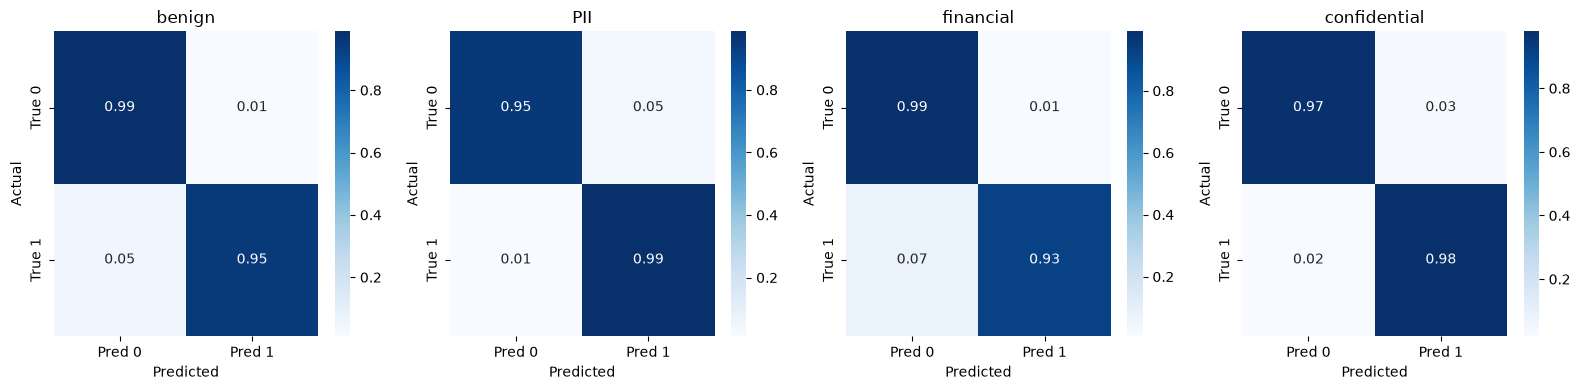

In [11]:
_, fig = plot_confusion_matrices(eval_y, y_pred_e, normalize="true", return_fig=True)
fig

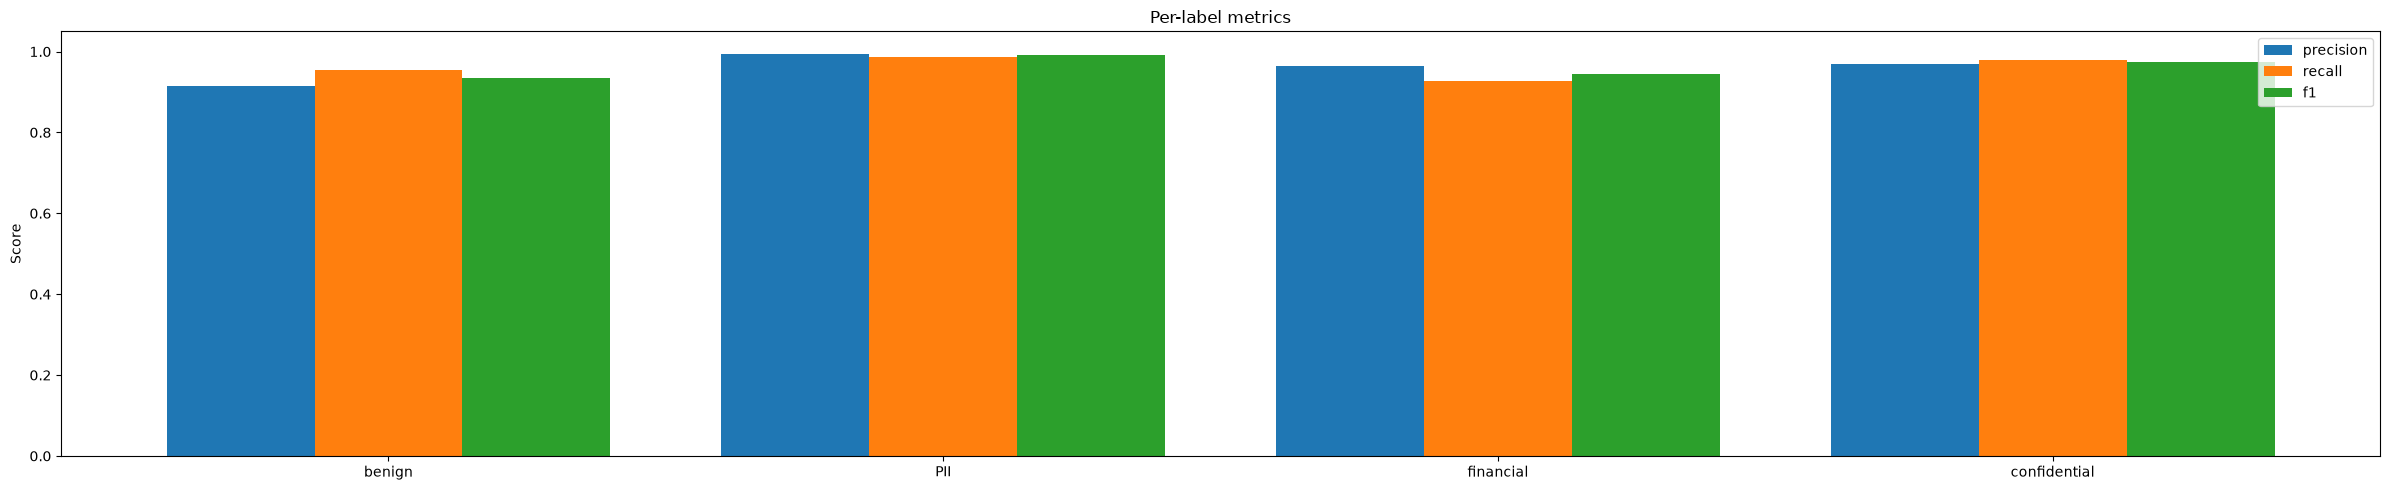

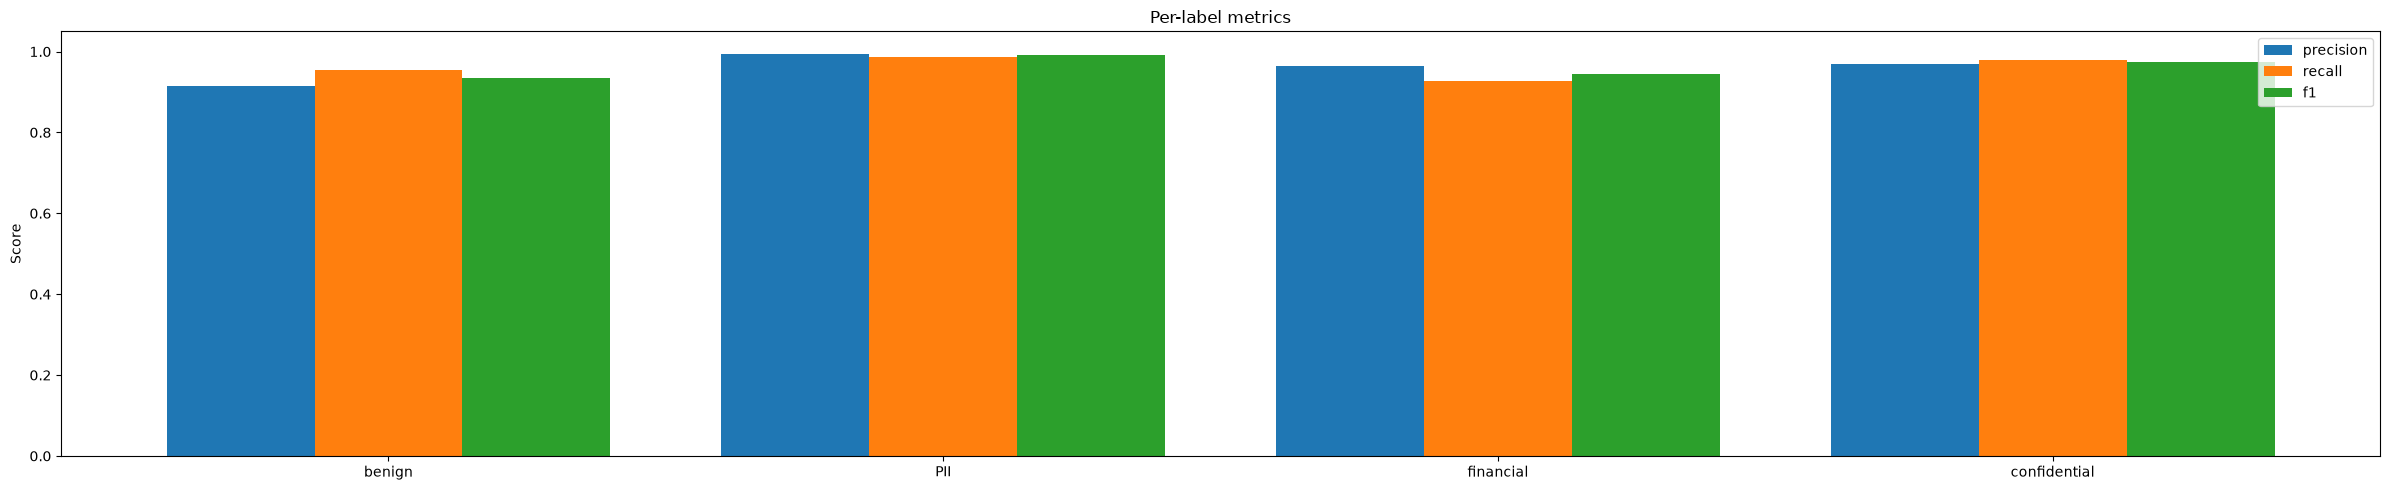

In [12]:
_, fig = plot_per_label_bars(metrics, return_fig=True)
fig

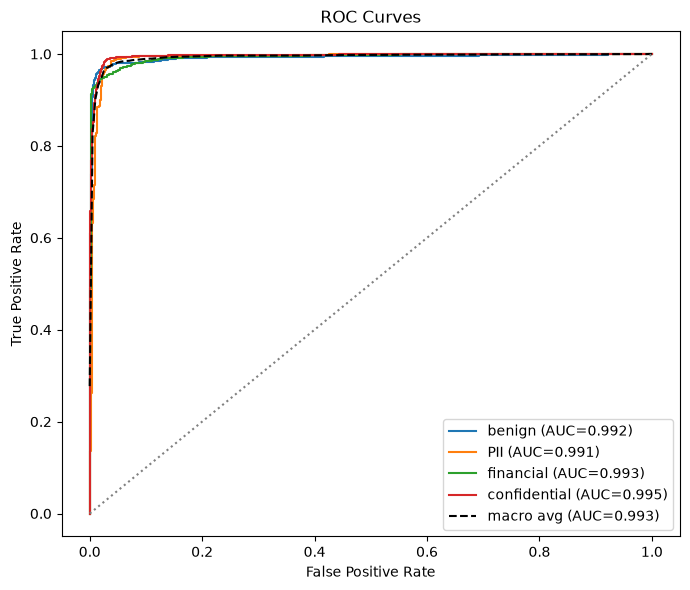

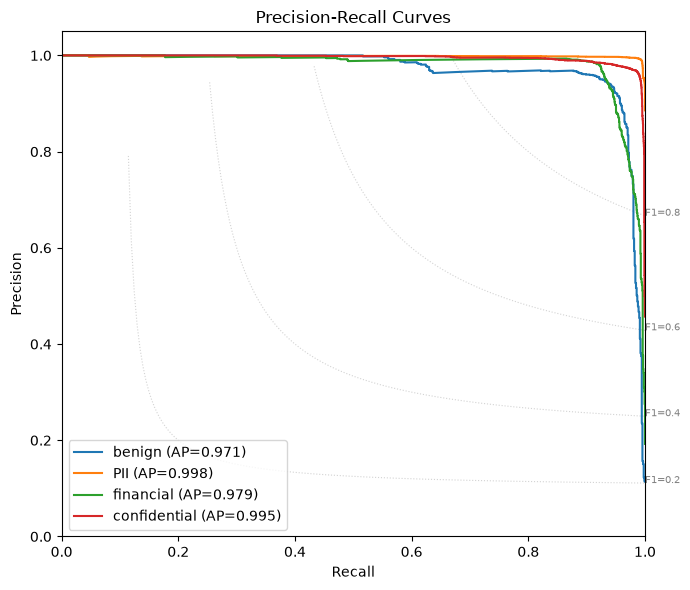

In [13]:
roc_data = plot_roc_curves(eval_y, y_proba_e)
pr_data = plot_pr_curves(eval_y, y_proba_e)

## 8. Save Results

In [14]:
out_path = RESULTS_DIR / "ensemble_metrics.json"

save_results(
    metrics,
    path=out_path,
    model_name="ensemble_weighted_fusion",
    n_samples=eval_y.shape[0],
    threshold=thresholds,
    extra_metadata={
        "fusion": "per-category weighted late fusion",
        "optimizer": "per-label grid + Nelder-Mead on true F1",
        "dev_split": "train_holdout",
        "test_split": "validation",
        "random_state": RANDOM_STATE,
        "weights": weights,
        "thresholds": thresholds,
    },
)
print(f"Saved to {out_path}")

Saved to /Users/erelv/projects-chkp/final-project/evaluation/results/ensemble_metrics.json


## 9. K-Fold Cross-Validation Results (Robustness Check)

5-fold CV over the ai4privacy `train` split (the `validation` TEST split is never touched here).
Per fold: each model is re-trained on the fold's training portion, ensemble weights are fit on
the fold's `inner_dev` partition, and every configuration is evaluated on the held-out test fold.

Results are loaded incrementally from `evaluation/results/kfold/fold{i}/ablation.csv` — only
completed folds appear. Re-run `python -m evaluation.kfold_cv --models <model>` to add a model;
the cells below update automatically on the next notebook run.

In [15]:
import json as _json

from evaluation import aggregate_folds, fold_scores, paired_fold_test

KFOLD_RESULTS_DIR = REPO_ROOT / "evaluation" / "results" / "kfold"
K = 5

# Load per-fold ablation tables — skip any fold whose ablation.csv is missing.
kfold_fold_tables = []
kfold_available_folds = []
for _fold_idx in range(K):
    _csv = KFOLD_RESULTS_DIR / f"fold{_fold_idx}" / "ablation.csv"
    if _csv.exists():
        kfold_fold_tables.append(pd.read_csv(_csv))
        kfold_available_folds.append(_fold_idx)

print(f"Completed folds: {kfold_available_folds}  ({len(kfold_available_folds)}/{K})")

if kfold_fold_tables:
    _configs_per_fold = [set(df["configuration"]) for df in kfold_fold_tables]
    _common = set.intersection(*_configs_per_fold)
    _all    = set.union(*_configs_per_fold)
    print(f"Configurations in ALL completed folds : {sorted(_common)}")
    if _all != _common:
        print(f"Configurations in SOME folds only    : {sorted(_all - _common)}")

Completed folds: [0, 1, 2, 3, 4]  (5/5)
Configurations in ALL completed folds : ['best_single', 'full_ensemble', 'solo_bilstm']


### 9a. Aggregated Table (mean ± std across completed folds)

In [16]:
if kfold_fold_tables:
    kfold_agg = aggregate_folds(kfold_fold_tables)

    # Build a human-readable summary: "mean ± std" strings for macro-F1 and per-label F1.
    _summary = kfold_agg[["configuration", "n_folds"]].copy()
    for _metric in ["macro_f1"] + [f"{l}_f1" for l in LABEL_COLS]:
        _mc, _sc = f"{_metric}_mean", f"{_metric}_std"
        if _mc in kfold_agg.columns:
            _summary[_metric] = kfold_agg.apply(
                lambda r, mc=_mc, sc=_sc: (
                    f"{r[mc]:.4f} ± {r[sc]:.4f}" if sc in r.index else f"{r[mc]:.4f}"
                ),
                axis=1,
            )
    _summary.set_index("configuration")
else:
    print("No k-fold fold results found yet — run `python -m evaluation.kfold_cv --models <model>` first.")

### 9b. Paired Fold Test: full_ensemble vs best_single

Caveat: with k=5 the paired t-test has low power and folds share training rows, so treat the
p-value as a descriptive robustness indicator rather than a strong significance claim.

In [17]:
if kfold_fold_tables:
    _ens   = fold_scores(kfold_fold_tables, "full_ensemble")
    _best  = fold_scores(kfold_fold_tables, "best_single")
    if len(_ens) >= 2 and len(_best) >= 2:
        _sig = paired_fold_test(_ens, _best)
        _p   = f"{_sig['p_value']:.4f}" if _sig["p_value"] is not None else "n/a"
        print(
            f"full_ensemble − best_single  "
            f"Δ={_sig['mean_delta']:+.4f}  paired-t p={_p}  n_folds={_sig['n_folds']}"
        )
    else:
        print(
            "Paired fold test skipped — 'full_ensemble' and/or 'best_single' appear in "
            f"fewer than 2 completed folds (ens={len(_ens)}, best={len(_best)})."
        )

full_ensemble − best_single  Δ=+0.0000  paired-t p=n/a  n_folds=5


### 9c. Per-Model K-Fold CV Summaries

Loaded from `evaluation/results/kfold_cv_{model}.json` — present only for models whose
single-model k-fold run has been completed (produced by `--models <model>` with a single-model
invocation, or from the combined run once all four models finish).

In [18]:
_ALL_MODELS = ["bert", "roberta", "bilstm", "rule_based"]
_model_cv_rows = []
for _m in _ALL_MODELS:
    _path = REPO_ROOT / "evaluation" / "results" / f"kfold_cv_{_m}.json"
    if not _path.exists():
        continue
    _data = _json.loads(_path.read_text())
    _agg  = _data.get("aggregated", {})
    _row  = {
        "model":    _m,
        "macro_f1": f"{_agg.get('macro_f1_mean', float('nan')):.4f} ± {_agg.get('macro_f1_std', float('nan')):.4f}",
        "n_folds":  _agg.get("n_folds", "?"),
    }
    for _label in LABEL_COLS:
        _pl = _agg.get("per_label", {}).get(_label, {})
        _row[f"{_label}_f1"] = (
            f"{_pl.get('f1_mean', float('nan')):.4f} ± {_pl.get('f1_std', float('nan')):.4f}"
        )
    _model_cv_rows.append(_row)

if _model_cv_rows:
    pd.DataFrame(_model_cv_rows).set_index("model")
else:
    print("No kfold_cv_*.json files found yet.")